# Fair MCA on Recruitment Data

This notebook studies fairness-aware Multiple Correspondence Analysis (MCA) on `recruitment_data.csv`.

Sensitive attribute: **gender**.
Methods compared:
- Classical MCA
- Hard Fair MCA
- Soft Fair MCA
- Indicator PCA
- Fair PCA

In [6]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

project_root = Path.cwd()
local_pkg = project_root / "fair_unsupervised_fairness"
metrics_src = local_pkg / "src"
if metrics_src.exists() and str(metrics_src) not in sys.path:
    sys.path.insert(0, str(metrics_src))

try:
    from fair_repr_eval.metrics import (
        adversarial_leakage_score,
        groupwise_mmd,
        percentage_variance_retained,
    )
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(local_pkg)])
    from fair_repr_eval.metrics import (
        adversarial_leakage_score,
        groupwise_mmd,
        percentage_variance_retained,
    )

sns.set_theme(style="whitegrid")

## 1) Load Data and Build Sensitive Attribute

In [7]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

print("Shape:", df.shape)
N_sub = df.shape[0] if df.shape[0] <= 5000 else df.shape[0] // 10
df = df.sample(n=N_sub, random_state=42).reset_index(drop=True)

col_map = {c.lower(): c for c in df.columns}
if "age" not in col_map:
    raise ValueError("Expected a 'age' column in bank-additional-full.csv")
age_col = col_map["age"]

age_raw = df[age_col]



age_labels = age_raw > 38

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Sensitive column:", age_col)
print("Sensitive proportion (group_1):", float(np.mean(age_labels)))

Shape: (41188, 21)
Shape: (4118, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Sensitive column: age
Sensitive proportion (group_1): 0.4868868382710053


## 2) Build MCA Indicator Matrix

In [8]:
exclude_cols = {age_col}
#for cand in ["HiringDecision", "hiringdecision", "target", "label"]:
#    if cand.lower() in col_map:
#        exclude_cols.add(col_map[cand.lower()])

feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols].copy()

# Convert numeric variables into quantile bins to keep MCA modality space manageable.
for c in X.columns:
    if pd.api.types.is_numeric_dtype(X[c]):
        x_num = pd.to_numeric(X[c], errors="coerce")
        nun = x_num.nunique(dropna=True)
        if nun > 8:
            X[c] = pd.qcut(x_num, q=4, duplicates="drop").astype(str)
        else:
            X[c] = x_num.round(0).astype("Int64").astype(str)
    else:
        X[c] = X[c].astype(str)

X = X.fillna("missing")
X_disj = pd.get_dummies(X, prefix_sep="=", dtype=float)

N = X_disj.values
n, m = N.shape

print("Feature columns used:", len(feature_cols))
print("Disjunctive table shape (n, m):", N.shape)

Feature columns used: 20
Disjunctive table shape (n, m): (4118, 86)


## 3) MCA + Fairness Utilities

In [9]:
import importlib
import methods

importlib.reload(methods)

from methods import ClassicMCA, IndicatorPCA, HardFairMCA, SoftFairMCA, FairPCA, FPCA, FPCAviaEigOpt

def make_Z_column_space(N, g_binary, eps=1e-12):
    # G_ind is n x 2 (male, female)
    G_ind = np.column_stack([1.0 - g_binary, g_binary])

    # Map individual sensitive info into column/modalities space: m x 2
    Z = N.T @ G_ind

    # Row-wise normalize to reduce pure frequency scale effects
    Z = Z / np.maximum(Z.sum(axis=1, keepdims=True), eps)
    return Z
def safe_corr(x, y, eps=1e-12):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    x = x - x.mean()
    y = y - y.mean()
    den = np.sqrt((x @ x) * (y @ y))
    if den < eps:
        return 0.0
    return float((x @ y) / den)


def component_gender_corr(F, g):
    return np.array([safe_corr(F[:, j], g) for j in range(F.shape[1])])

def component_mean_abs_corr(F, G_ind):
    # Returns mean absolute corr across all sensitive groups for each component
    out = []
    for j in range(F.shape[1]):
        vals = [abs(safe_corr(F[:, j], G_ind[:, t])) for t in range(G_ind.shape[1])]
        out.append(np.mean(vals) if vals else 0.0)
    return np.asarray(out)

## 4) Run Classical, Hard Fair, and Soft Fair MCA

In [13]:
k = 10
lambda_fair = 0.001


Z = make_Z_column_space(N, age_labels)

Z_stack = np.column_stack([1.0 - age_labels, age_labels])  #

res_classic = ClassicMCA(N, k=k).fit()
res_hard = HardFairMCA(N, Z=Z, k=k).fit()
res_soft = SoftFairMCA(N, Z=Z, k=k, lambda_fair=lambda_fair).fit()
res_pca = IndicatorPCA(N, k=k).fit()
res_fpca = FairPCA(N, Z=Z, k=k).fit()
res_fPCA = FPCA(N, Z=Z_stack, k=k).fit()
res_fPCA_eigopt = FPCAviaEigOpt(N, Z=Z_stack, k=k).fit()

method_embeddings = {
    "classic": res_classic.F,
    "hard": res_hard.F,
    "soft": res_soft.F,
    "pca": res_pca.F,
    "fair_pca": res_fpca.F,
    "fPCA": res_fPCA.F,
    "fPCA_eigopt": res_fPCA_eigopt.F,
}
metric_rows = []
for method, emb in method_embeddings.items():
    mmd = groupwise_mmd(emb, age_labels)
    adv = adversarial_leakage_score(emb, age_labels)
    metric_rows.append({
        "method": method,
        "rho_mean": np.mean(np.abs(component_gender_corr(emb, age_labels))),
        "variance_retained_percent": percentage_variance_retained(N, emb),
        "mmd_mean": mmd["mean"],
        "deltaAccuracy": np.abs(adv["accuracy_mean"] - adv["majority_class_baseline"]),
    })

fair_metrics = pd.DataFrame(metric_rows).sort_values("method").reset_index(drop=True)

fair_metrics

FPCA fit completed for m_used=10.
Projection matrix shape: (86, 86)


,method,rho_mean,variance_retained_percent,mmd_mean,deltaAccuracy
0,classic,0.076553,41.026907,0.010909,0.111708
1,fPCA,0.093311,40.500970,0.012755,0.131138
2,fPCA_eigopt,0.095153,29.306280,0.016614,0.114623
3,fair_pca,0.039140,37.847761,0.005486,0.031329
4,hard,0.015701,37.575666,0.000480,0.003398
5,pca,0.059583,40.450332,0.013957,0.131622
6,soft,0.013985,37.919158,0.000564,0.001456


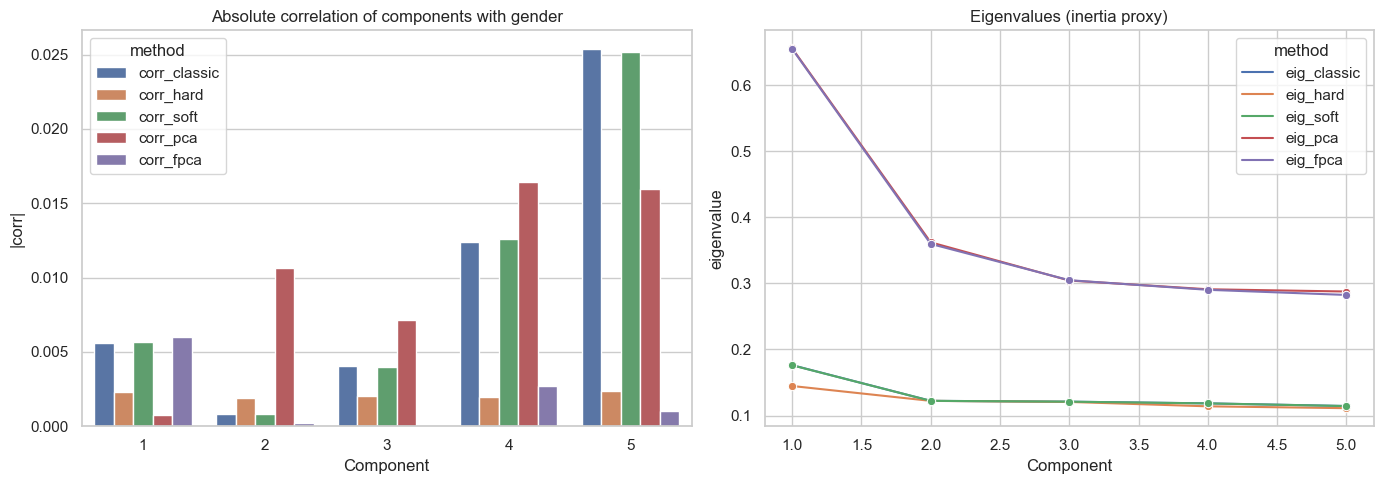

In [ ]:
lambda_fair = 0.001
metric_rows = []

Z = make_Z_column_space(N, age_labels)

Z_stack = np.column_stack([1.0 - age_labels, age_labels])  #

for k in range(1, 11):

    res_soft = SoftFairMCA(N, Z=Z, k=k, lambda_fair=lambda_fair).fit()
    emb = res_soft.F

    mmd = groupwise_mmd(emb, age_labels)
    adv = adversarial_leakage_score(emb, age_labels)
    metric_rows.append({
        "components": k,
        "rho_mean": np.mean(np.abs(component_gender_corr(emb, age_labels))),
        "variance_retained_percent": percentage_variance_retained(N, emb),
        "mmd_mean": mmd["mean"],
        "deltaAccuracy": np.abs(adv["accuracy_mean"] - adv["majority_class_baseline"]),
    })

fair_metrics = pd.DataFrame(metric_rows).sort_values("components").reset_index(drop=True)

fair_metrics

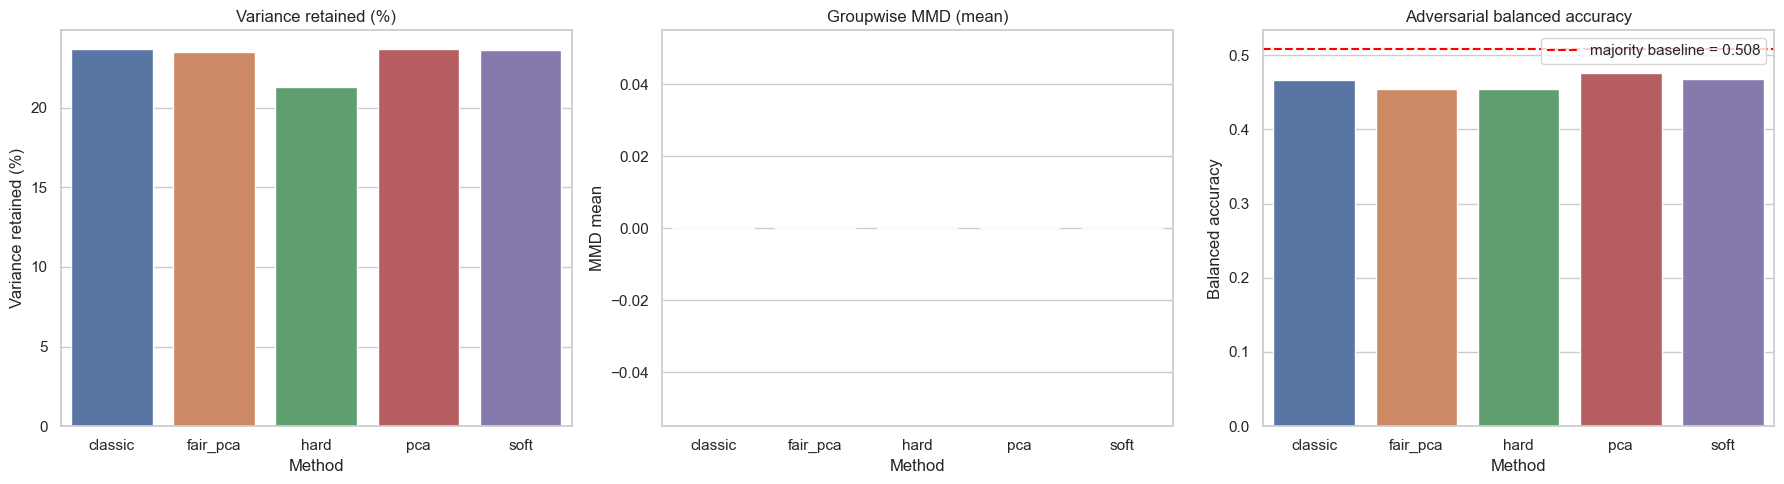

In [ ]:
k = 10
metric_rows = []

lambda_grid = np.array([0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1])


Z = make_Z_column_space(N, age_labels)

Z_stack = np.column_stack([1.0 - age_labels, age_labels])  #

for lambda_fair in lambda_grid:

    res_soft = SoftFairMCA(N, Z=Z, k=k, lambda_fair=lambda_fair).fit()
    emb = res_soft.F

    mmd = groupwise_mmd(emb, age_labels)
    adv = adversarial_leakage_score(emb, age_labels)
    metric_rows.append({
        "lambda_fair": lambda_fair,
        "rho_mean": np.mean(np.abs(component_gender_corr(emb, age_labels))),
        "variance_retained_percent": percentage_variance_retained(N, emb),
        "mmd_mean": mmd["mean"],
        "deltaAccuracy": np.abs(adv["accuracy_mean"] - adv["majority_class_baseline"]),
    })

fair_metrics = pd.DataFrame(metric_rows).sort_values("lambda_fair").reset_index(drop=True)

fair_metrics

## 5) Adversarial Study on Gender Leakage

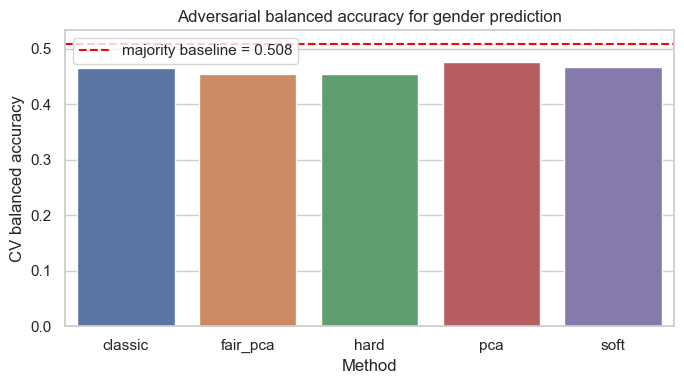

In [17]:
adv_df = fair_metrics[[
    "method",
    "adversarial_balanced_accuracy_mean",
    "adversarial_majority_class_baseline",
]].copy()
adv_df

plt.figure(figsize=(7, 4))
sns.barplot(data=adv_df, x="method", y="adversarial_balanced_accuracy_mean")
baseline = float(adv_df["adversarial_majority_class_baseline"].iloc[0])
plt.axhline(baseline, color="red", linestyle="--", label=f"majority baseline = {baseline:.3f}")
plt.title("Adversarial balanced accuracy for gender prediction")
plt.ylabel("CV balanced accuracy")
plt.xlabel("Method")
plt.legend()
plt.tight_layout()
plt.show()

## 6) Lambda_fair Sensitivity Study

In [18]:
lambda_grid = np.array([0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1.0])
lambda_rows = []

for lam in lambda_grid:
    res_lam = soft_fair_mca(N, Z=Z, k=k, lambda_fair=float(lam))
    corr_lam = component_sensitive_corr(res_lam["F"], g)
    mmd_lam = groupwise_mmd(res_lam["F"], gender_labels)
    adv_lam = adversarial_leakage_score(res_lam["F"], gender_labels)
    lambda_rows.append({
        "lambda_fair": float(lam),
        "mean_abs_corr": float(np.mean(np.abs(corr_lam))) if len(corr_lam) else 0.0,
        "sum_eigenvalues": float(np.sum(res_lam["eigenvalues"])),
        "mmd_mean": mmd_lam["mean"],
        "adv_balanced_accuracy": adv_lam["balanced_accuracy_mean"],
    })

lambda_study = pd.DataFrame(lambda_rows)
lambda_study

,lambda_fair,mean_abs_corr,sum_eigenvalues,mmd_mean,adv_balanced_accuracy
0,0.00000,0.009633,0.652377,0.0,0.466279
1,0.00001,0.009643,0.652103,0.0,0.467595
2,0.00005,0.009679,0.651025,0.0,0.468239
3,0.00010,0.009713,0.649727,0.0,0.466816
4,0.00050,0.009627,0.641138,0.0,0.465312
5,0.00100,0.008600,0.633984,0.0,0.475346
6,0.00500,0.004588,0.618961,0.0,0.462228
7,0.01000,0.002980,0.615962,0.0,0.456187
8,0.05000,0.001502,0.613342,0.0,0.451511
9,0.10000,0.001782,0.612997,0.0,0.452912


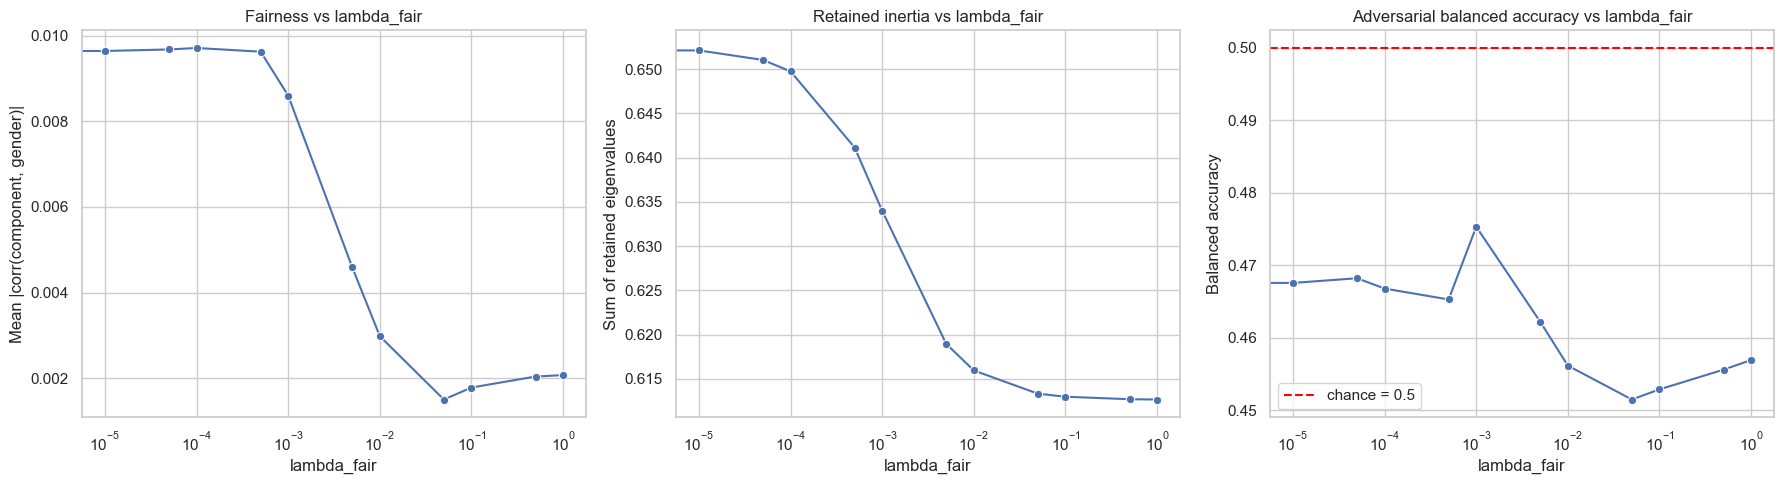

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=lambda_study, x="lambda_fair", y="mean_abs_corr", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Fairness vs lambda_fair")
axes[0].set_ylabel("Mean |corr(component, gender)|")
axes[0].set_xlabel("lambda_fair")

sns.lineplot(data=lambda_study, x="lambda_fair", y="sum_eigenvalues", marker="o", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Retained inertia vs lambda_fair")
axes[1].set_ylabel("Sum of retained eigenvalues")
axes[1].set_xlabel("lambda_fair")

sns.lineplot(data=lambda_study, x="lambda_fair", y="adv_balanced_accuracy", marker="o", ax=axes[2])
axes[2].set_xscale("log")
axes[2].axhline(0.5, color="red", linestyle="--", label="chance = 0.5")
axes[2].set_title("Adversarial balanced accuracy vs lambda_fair")
axes[2].set_ylabel("Balanced accuracy")
axes[2].set_xlabel("lambda_fair")
axes[2].legend()

plt.tight_layout()
plt.show()

## 7) Notes

- Hard Fair MCA should generally reduce correlation with gender more aggressively, with higher inertia cost.
- Soft Fair MCA provides a smooth trade-off controlled by `lambda_fair`.
- Use the lambda sweep and adversarial metric together to pick an operating point.